# Cornell Movie Dialogs → Gemini API → Character Relationship Extraction → Knowledge Graph

重點是把一部電影的所有台詞整理成可供 LLM 抽取角色關係的資料流，並且輸出成之後可建 Knowledge Graph 的格式。

---

## 這份 notebook 會做什麼

1. 載入 Cornell Movie Dialogs Corpus  
2. 選取一部電影  
3. 重建該電影所有台詞 turn 順序  
4. 用 **speaker 欄位** 當第一層角色名稱來源  
5. 切成適合 Gemini 的 chunks  
6. 對每個 chunk 做角色與關係抽取  
7. 驗證 JSON schema  
8. 合併所有 chunk 的關係  
9. 對角色名稱做 canonicalization / alias merge  
10. 匯出 `nodes` / `edges` 給 KG 使用

---

## 角色名稱是不是可以直接用 speaker 欄位？

### 分成兩層概念：

#### 第一層：speaker name
資料裡每句台詞自帶的 speaker / character_name。  
這個非常適合當作：

- turn-level speaker 標記
- prompt 裡的說話者名字
- 初始角色候選名

#### 第二層：canonical character name
最後 Knowledge Graph 要用的角色標準名。  
通常不能完全等同於 speaker 欄位，因為可能有：

- 縮寫：`Kat`
- 全名：`Kat Stratford`
- 別名：`Katarina`
- 拼法不一致
- 大小寫不一致

所以最穩的做法是：

1. **先直接用 speaker 欄位**
2. **LLM 依 speaker 內容抽角色與關係**
3. **最後再做 canonicalization / alias merge**

### 結論
- **prompt 裡：可以直接用 speaker 欄位**
- **最終 graph 節點：建議用 merge 後的 canonical name**

---

## notebook 使用建議

第一次跑請先：

- `RUN_GEMINI = False`
- 檢查 chunk 結構與中間表格
- 再改成 `RUN_GEMINI = True`
- 用 `MAX_CHUNKS_TO_RUN = 2` 先測


In [36]:
# ============================================================
# 0. Install packages if needed
# ============================================================

# Uncomment if needed:
# %pip install -U google-genai pydantic pandas networkx matplotlib


In [38]:
# ============================================================
# 1. Imports
# ============================================================

import ast
import json
import os
import random
import re
import time
from collections import Counter, defaultdict
from dataclasses import dataclass, field
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple

import pandas as pd
from pydantic import BaseModel, Field, ValidationError

try:
    from google import genai
except Exception:
    genai = None


## 2. Configuration

主要需要改這幾個參數：

- `DATA_DIR`
- `MOVIE_TITLE_QUERY`
- `GEMINI_API_KEY`
- `RUN_GEMINI`


In [39]:
# ============================================================
# 2. Configuration
# ============================================================

DATA_DIR = Path("./cornell_movie_dialogs_corpus")

MOVIE_TITLE_QUERY = "Titanic"

# Whether to actually call Gemini
RUN_GEMINI = False
GEMINI_API_KEY = os.getenv("GEMINI_API_KEY", "")
GEMINI_MODEL = "gemini-3.1-flash-lite-preview"

# Chunking
MAX_TURNS_PER_CHUNK = 40
CHUNK_OVERLAP_TURNS = 8
MAX_APPROX_CHARS_PER_CHUNK = 6000

# Execution controls
MAX_CHUNKS_TO_RUN = None     # e.g. 2 for testing
SKIP_EXISTING_CHUNK_FILES = True

# Retry
MAX_RETRIES = 4
INITIAL_RETRY_DELAY_SEC = 2.0
JITTER_SEC = 0.8
SLEEP_BETWEEN_CALLS_SEC = 0.5

# Output
OUTPUT_DIR = Path("./outputs_cornell_gemini_complete")
CHUNK_OUTPUT_DIR = OUTPUT_DIR / "chunk_results"
LOG_DIR = OUTPUT_DIR / "logs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CHUNK_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
LOG_DIR.mkdir(parents=True, exist_ok=True)

print("OUTPUT_DIR:", OUTPUT_DIR.resolve())


OUTPUT_DIR: /mnt/c/Users/jackyfirst/Downloads/knowledge graph/outputs_cornell_gemini_complete


## 3. Load Cornell dataset


In [40]:
# ============================================================
# 3. Load Cornell dataset
# ============================================================

SEP = " +++$+++ "

def read_split_file(path: Path, expected_cols: int) -> List[List[str]]:
    rows = []
    with open(path, "r", encoding="iso-8859-1") as f:
        for line in f:
            parts = line.rstrip("\n").split(SEP)
            if len(parts) < expected_cols:
                parts = parts + [""] * (expected_cols - len(parts))
            rows.append(parts[:expected_cols])
    return rows

def load_cornell_dataset(data_dir: Path):
    lines_path = data_dir / "movie_lines.txt"
    convs_path = data_dir / "movie_conversations.txt"
    titles_path = data_dir / "movie_titles_metadata.txt"
    chars_path = data_dir / "movie_characters_metadata.txt"

    for p in [lines_path, convs_path, titles_path, chars_path]:
        if not p.exists():
            raise FileNotFoundError(f"Cannot find required file: {p}")

    lines_rows = read_split_file(lines_path, 5)
    conv_rows = read_split_file(convs_path, 4)
    title_rows = read_split_file(titles_path, 6)
    char_rows = read_split_file(chars_path, 6)

    df_lines = pd.DataFrame(
        lines_rows,
        columns=["line_id", "character_id", "movie_id", "character_name", "text"]
    )

    df_convs = pd.DataFrame(
        conv_rows,
        columns=["character_id_1", "character_id_2", "movie_id", "utterance_ids_raw"]
    )

    df_titles = pd.DataFrame(
        title_rows,
        columns=["movie_id", "title", "year", "rating", "votes", "genres_raw"]
    )

    df_chars = pd.DataFrame(
        char_rows,
        columns=["character_id", "character_name", "movie_id", "movie_title", "gender", "position"]
    )

    return df_lines, df_convs, df_titles, df_chars

df_lines, df_convs, df_titles, df_chars = load_cornell_dataset(DATA_DIR)

print("df_lines shape:", df_lines.shape)
print("df_convs shape:", df_convs.shape)
print("df_titles shape:", df_titles.shape)
print("df_chars shape:", df_chars.shape)
display(df_titles.head())


df_lines shape: (304713, 5)
df_convs shape: (83097, 4)
df_titles shape: (617, 6)
df_chars shape: (9035, 6)


,movie_id,title,year,rating,votes,genres_raw
0,m0,10 things i hate about you,1999,6.90,62847,"['comedy', 'romance']"
1,m1,1492: conquest of paradise,1992,6.20,10421,"['adventure', 'biography', 'drama', 'history']"
2,m2,15 minutes,2001,6.10,25854,"['action', 'crime', 'drama', 'thriller']"
3,m3,2001: a space odyssey,1968,8.40,163227,"['adventure', 'mystery', 'sci-fi']"
4,m4,48 hrs.,1982,6.90,22289,"['action', 'comedy', 'crime', 'drama', 'thrill..."


## 4. Select one movie


In [45]:
# ============================================================
# 4. Select one movie
# ============================================================

def normalize_text(s: str) -> str:
    s = s.lower().strip()
    s = re.sub(r"\s+", " ", s)
    return s

def find_movie_by_title(df_titles: pd.DataFrame, title_query: str) -> pd.DataFrame:
    q = normalize_text(title_query)
    tmp = df_titles.copy()
    tmp["title_norm"] = tmp["title"].fillna("").map(normalize_text)

    exact = tmp[tmp["title_norm"] == q]
    if not exact.empty:
        return exact.drop(columns=["title_norm"])

    contains = tmp[tmp["title_norm"].str.contains(re.escape(q), na=False)]
    if not contains.empty:
        return contains.drop(columns=["title_norm"])

    return tmp.iloc[0:0].drop(columns=["title_norm"])

movie_matches = find_movie_by_title(df_titles, MOVIE_TITLE_QUERY)

if movie_matches.empty:
    raise ValueError(f"No movie title matched query: {MOVIE_TITLE_QUERY}")

display(movie_matches[["movie_id", "title", "year", "genres_raw"]].head(10))

selected_movie = movie_matches.iloc[0].to_dict()
SELECTED_MOVIE_ID = selected_movie["movie_id"]
SELECTED_MOVIE_TITLE = selected_movie["title"]

print("Selected movie:", SELECTED_MOVIE_ID, SELECTED_MOVIE_TITLE)


,movie_id,title,year,genres_raw
574,m574,titanic,1997,"['drama', 'history', 'romance']"


Selected movie: m574 titanic


## 5. Reconstruct all dialogue turns

後面 chunk 與 evidence turn ids 都依賴這個 turn-level table。

### 關於 speaker
這裡的 `speaker_name` 就是從 Cornell 原始資料的 `character_name` 來。  

In [46]:
# ============================================================
# 5. Reconstruct all turns
# ============================================================

def parse_utterance_id_list(raw: str) -> List[str]:
    try:
        ids = ast.literal_eval(raw)
        if isinstance(ids, list):
            return [str(x) for x in ids]
    except Exception:
        pass
    return []

def build_movie_dialogue(movie_id: str, df_lines: pd.DataFrame, df_convs: pd.DataFrame, df_chars: pd.DataFrame):
    lines_sub = df_lines[df_lines["movie_id"] == movie_id].copy()
    convs_sub = df_convs[df_convs["movie_id"] == movie_id].copy()
    chars_sub = df_chars[df_chars["movie_id"] == movie_id].copy()

    line_map = lines_sub.set_index("line_id").to_dict("index")
    char_meta = chars_sub.set_index("character_id").to_dict("index")

    all_turns = []
    all_convs = []

    for conv_idx, row in convs_sub.reset_index(drop=True).iterrows():
        utt_ids = parse_utterance_id_list(row["utterance_ids_raw"])
        conv_turns = []

        for turn_idx, line_id in enumerate(utt_ids):
            if line_id not in line_map:
                continue

            info = line_map[line_id]
            char_id = str(info["character_id"])
            speaker_name = str(info["character_name"]).strip()
            text = str(info["text"]).strip()

            meta = char_meta.get(char_id, {})
            conv_turn = {
                "movie_id": movie_id,
                "conversation_id": f"{movie_id}_conv_{conv_idx}",
                "conversation_index": conv_idx,
                "turn_index_in_conversation": turn_idx,
                "global_turn_index": None,
                "line_id": line_id,
                "character_id": char_id,
                "speaker_name": speaker_name,
                "speaker_gender": meta.get("gender", ""),
                "speaker_position": meta.get("position", ""),
                "text": text,
            }
            conv_turns.append(conv_turn)

        all_convs.append({
            "movie_id": movie_id,
            "conversation_id": f"{movie_id}_conv_{conv_idx}",
            "conversation_index": conv_idx,
            "n_turns": len(conv_turns),
            "turns": conv_turns,
        })
        all_turns.extend(conv_turns)

    for i, turn in enumerate(all_turns):
        turn["global_turn_index"] = i

    movie_turns_df = pd.DataFrame(all_turns)
    movie_conversations_df = pd.DataFrame(all_convs)
    return movie_turns_df, movie_conversations_df

movie_turns_df, movie_conversations_df = build_movie_dialogue(
    SELECTED_MOVIE_ID, df_lines, df_convs, df_chars
)

print("movie_turns_df shape:", movie_turns_df.shape)
print("movie_conversations_df shape:", movie_conversations_df.shape)
display(movie_turns_df.head(10))


movie_turns_df shape: (397, 11)
movie_conversations_df shape: (136, 5)


,movie_id,conversation_id,conversation_index,turn_index_in_conversation,global_turn_index,line_id,character_id,speaker_name,speaker_gender,speaker_position,text
0,m574,m574_conv_0,0,0,0,L614987,u8446,ANDREWS,?,?,Water 14 feet above the keel in ten minutes......
1,m574,m574_conv_0,0,1,1,L614988,u8464,SMITH,?,?,That's right.
2,m574,m574_conv_0,0,2,2,L614989,u8446,ANDREWS,?,?,Five compartments. She can stay afloat with th...
3,m574,m574_conv_0,0,3,3,L614990,u8464,SMITH,?,?,The pumps --
4,m574,m574_conv_0,0,4,4,L614991,u8446,ANDREWS,?,?,The pumps buy you time... but minutes only. Fr...
5,m574,m574_conv_1,1,0,5,L614994,u8464,SMITH,?,?,How much time?
6,m574,m574_conv_1,1,1,6,L614995,u8446,ANDREWS,?,?,"An hour, two at most."
7,m574,m574_conv_2,2,0,7,L614754,u8462,ROSE,f,2,"Your ship is a wonder, Mr. Andrews. Truly."
8,m574,m574_conv_2,2,1,8,L614755,u8446,ANDREWS,?,?,"Thank you, Rose."
9,m574,m574_conv_3,3,0,9,L614829,u8462,ROSE,f,2,"Mr. Andrews, I did the sum in my head, and wit..."


## 6. Inspect speaker quality
 
先檢查 speaker_name 是否足夠乾淨，能不能直接拿來當角色初始名。


In [47]:
# ============================================================
# 6. Inspect speaker field quality
# ============================================================

movie_turns_df["speaker_name"] = movie_turns_df["speaker_name"].fillna("").astype(str).str.strip()
movie_turns_df["text"] = movie_turns_df["text"].fillna("").astype(str).str.strip()

print("Total turns:", len(movie_turns_df))
print("Empty text turns:", (movie_turns_df["text"] == "").sum())
print("Unique speaker names:", movie_turns_df["speaker_name"].nunique())

speaker_counts = movie_turns_df["speaker_name"].value_counts().reset_index()
speaker_counts.columns = ["speaker_name", "n_turns"]

display(speaker_counts.head(20))

print("Sample turns:")
for _, r in movie_turns_df.head(12).iterrows():
    print(f"[{r['global_turn_index']:04d}] {r['speaker_name']}: {r['text']}")


Total turns: 397
Empty text turns: 0
Unique speaker names: 19


,speaker_name,n_turns
0,ROSE,127
1,JACK,100
2,CAL,40
3,LOVETT,29
4,ANDREWS,14
5,RUTH,12
6,SMITH,10
7,BODINE,10
8,LIZZY,9
9,LOVEJOY,6


Sample turns:
[0000] ANDREWS: Water 14 feet above the keel in ten minutes... in the forepeak... in all three holds... and in boiler room six.
[0001] SMITH: That's right.
[0002] ANDREWS: Five compartments. She can stay afloat with the first four compartments breached. But not five. Not five. As she goes down by the head the water will spill over the tops of the bulkheads... at E Deck... from one to the next... back and back. There's no stopping it.
[0003] SMITH: The pumps --
[0004] ANDREWS: The pumps buy you time... but minutes only. From this moment, no matter what we do, Titanic will founder.
[0005] SMITH: How much time?
[0006] ANDREWS: An hour, two at most.
[0007] ROSE: Your ship is a wonder, Mr. Andrews. Truly.
[0008] ANDREWS: Thank you, Rose.
[0009] ROSE: Mr. Andrews, I did the sum in my head, and with the number of lifeboats times the capacity you mentioned... forgive me, but it seems that there are not enough for everyone aboard.
[0010] ANDREWS: About half, actually. Rose, you mi

## 7. Why use speaker as the first-layer name?

### 優點
- Cornell 已經幫把每句台詞對應到角色
- prompt 給 LLM 時很直觀
- 後面 evidence turn 也容易對回去

### 風險
- speaker_name 不一定是最後最理想的 graph 節點名
- 同一角色可能有不同寫法
- 有時需要再和 alias 合併

### 建議：
- `speaker_name` = turn-level name
- `canonical_name` = merge 後 graph-level name


## 8. Chunking


In [49]:
# ============================================================
# 8. Chunking
# ============================================================

@dataclass
class DialogueTurn:
    global_turn_index: int
    conversation_id: str
    line_id: str
    character_id: str
    speaker_name: str
    text: str

@dataclass
class DialogueChunk:
    chunk_id: str
    movie_id: str
    movie_title: str
    start_turn: int
    end_turn: int
    conversation_ids: List[str]
    turns: List[DialogueTurn] = field(default_factory=list)

    def to_prompt_text(self) -> str:
        lines = []
        for t in self.turns:
            lines.append(
                f"[turn={t.global_turn_index}][speaker={t.speaker_name}][line_id={t.line_id}] {t.text}"
            )
        return "\n".join(lines)

def build_turn_objects(movie_turns_df: pd.DataFrame) -> List[DialogueTurn]:
    turns = []
    for _, r in movie_turns_df.iterrows():
        turns.append(DialogueTurn(
            global_turn_index=int(r["global_turn_index"]),
            conversation_id=str(r["conversation_id"]),
            line_id=str(r["line_id"]),
            character_id=str(r["character_id"]),
            speaker_name=str(r["speaker_name"]),
            text=str(r["text"]),
        ))
    return turns

def chunk_turns(
    turns: List[DialogueTurn],
    movie_id: str,
    movie_title: str,
    max_turns: int = 40,
    overlap_turns: int = 8,
    max_approx_chars: int = 6000
) -> List[DialogueChunk]:
    chunks = []
    n = len(turns)
    start = 0
    chunk_idx = 0

    while start < n:
        end = min(start + max_turns, n)

        while end > start + 1:
            approx_len = sum(len(turns[i].text) + len(turns[i].speaker_name) + 30 for i in range(start, end))
            if approx_len <= max_approx_chars:
                break
            end -= 1

        chunk_turns_list = turns[start:end]
        conv_ids = list(dict.fromkeys([t.conversation_id for t in chunk_turns_list]))

        chunks.append(DialogueChunk(
            chunk_id=f"{movie_id}_chunk_{chunk_idx:04d}",
            movie_id=movie_id,
            movie_title=movie_title,
            start_turn=chunk_turns_list[0].global_turn_index,
            end_turn=chunk_turns_list[-1].global_turn_index,
            conversation_ids=conv_ids,
            turns=chunk_turns_list
        ))

        if end == n:
            break

        start = max(end - overlap_turns, start + 1)
        chunk_idx += 1

    return chunks

turn_objects = build_turn_objects(movie_turns_df)
chunks = chunk_turns(
    turn_objects,
    SELECTED_MOVIE_ID,
    SELECTED_MOVIE_TITLE,
    max_turns=MAX_TURNS_PER_CHUNK,
    overlap_turns=CHUNK_OVERLAP_TURNS,
    max_approx_chars=MAX_APPROX_CHARS_PER_CHUNK
)

chunk_summary = pd.DataFrame([
    {
        "chunk_id": c.chunk_id,
        "start_turn": c.start_turn,
        "end_turn": c.end_turn,
        "n_turns": len(c.turns),
        "n_conversations": len(c.conversation_ids),
        "approx_chars": len(c.to_prompt_text()),
    }
    for c in chunks
])

print("Number of chunks:", len(chunks))
display(chunk_summary.head(10))

print("=" * 100)
print(chunks[0].chunk_id, f"(turns {chunks[0].start_turn} ~ {chunks[0].end_turn})")
print(chunks[0].to_prompt_text()[:2500])


Number of chunks: 13


,chunk_id,start_turn,end_turn,n_turns,n_conversations,approx_chars
0,m574_chunk_0000,0,39,40,14,4496
1,m574_chunk_0001,32,71,40,14,4427
2,m574_chunk_0002,64,103,40,16,4023
3,m574_chunk_0003,96,135,40,17,3939
4,m574_chunk_0004,128,167,40,17,4060
5,m574_chunk_0005,160,199,40,13,4521
6,m574_chunk_0006,192,231,40,8,4268
7,m574_chunk_0007,224,263,40,10,4166
8,m574_chunk_0008,256,295,40,14,4301
9,m574_chunk_0009,288,327,40,16,3206


m574_chunk_0000 (turns 0 ~ 39)
[turn=0][speaker=ANDREWS][line_id=L614987] Water 14 feet above the keel in ten minutes... in the forepeak... in all three holds... and in boiler room six.
[turn=1][speaker=SMITH][line_id=L614988] That's right.
[turn=2][speaker=ANDREWS][line_id=L614989] Five compartments. She can stay afloat with the first four compartments breached. But not five. Not five. As she goes down by the head the water will spill over the tops of the bulkheads... at E Deck... from one to the next... back and back. There's no stopping it.
[turn=3][speaker=SMITH][line_id=L614990] The pumps --
[turn=4][speaker=ANDREWS][line_id=L614991] The pumps buy you time... but minutes only. From this moment, no matter what we do, Titanic will founder.
[turn=5][speaker=SMITH][line_id=L614994] How much time?
[turn=6][speaker=ANDREWS][line_id=L614995] An hour, two at most.
[turn=7][speaker=ROSE][line_id=L614754] Your ship is a wonder, Mr. Andrews. Truly.
[turn=8][speaker=ANDREWS][line_id=L614755] 

## 9. Structured output schema

- LLM 輸入看見的是 `speaker`
- LLM 輸出的是：
  - `canonical_name`
  - `aliases`
  - `relationships`

**speaker 是輸入來源，canonical_name 是輸出整理後角色名。**


In [50]:
# ============================================================
# 9. Pydantic schema
# ============================================================

RELATION_TYPES = [
    "family",
    "romantic_interest",
    "ex_partner",
    "friendship",
    "rivalry",
    "mentor",
    "subordinate",
    "suspicion",
    "alliance",
    "conflict",
    "respect",
    "dependency",
    "unknown",
]

POLARITY_TYPES = [
    "positive",
    "negative",
    "mixed",
    "uncertain",
]

class CharacterEntity(BaseModel):
    canonical_name: str = Field(description="Canonical character name for this chunk")
    aliases: List[str] = Field(default_factory=list, description="Alias list that includes speaker-level variants")
    source_speakers: List[str] = Field(default_factory=list, description="Speaker names in the raw chunk that refer to this character")
    description: str = Field(default="", description="Local character description from the chunk")

class RelationshipEdge(BaseModel):
    source: str
    target: str
    relation_type: str
    relation_label: str
    polarity: str
    directional: bool
    confidence: float
    evidence_turn_ids: List[int] = Field(default_factory=list)
    evidence_quotes: List[str] = Field(default_factory=list)
    notes: str = ""

class ChunkExtractionResult(BaseModel):
    movie_title: str
    chunk_id: str
    characters: List[CharacterEntity] = Field(default_factory=list)
    relationships: List[RelationshipEdge] = Field(default_factory=list)
    summary: str = ""


## 10. Prompt design

這裡會明確告訴 Gemini：

- speaker 欄位是原始台詞說話者名稱
- 它可以把多個 speaker 變體合併成同一 canonical_name
- 但不能憑空發明角色


In [51]:
# ============================================================
# 10. Prompt builder
# ============================================================

def build_extraction_prompt(chunk: DialogueChunk) -> str:
    return f'''
You are an expert information extraction system for movie dialogue analysis.

Your task:
Extract characters and interpersonal relationships from the dialogue chunk below.

Important instructions:
1. The value inside [speaker=...] is the raw speaker name from the dataset.
2. You may use speaker names as the first-layer character references.
3. If multiple speaker names appear to refer to the same character, merge them into one canonical_name and list the raw forms under aliases and source_speakers.
4. Do NOT invent characters not supported by the chunk.
5. Use ONLY the provided chunk content.
6. Distinguish temporary emotion from longer-term or developing relationship patterns.
7. Each relationship must include evidence_turn_ids and short evidence_quotes.
8. relation_type must be one of: {RELATION_TYPES}
9. polarity must be one of: {POLARITY_TYPES}
10. confidence must be between 0 and 1.
11. Return structured JSON only.

Metadata:
movie_title = {chunk.movie_title}
chunk_id = {chunk.chunk_id}
turn_range = [{chunk.start_turn}, {chunk.end_turn}]

Dialogue chunk:
{chunk.to_prompt_text()}
'''.strip()

print(build_extraction_prompt(chunks[0])[:3200])


You are an expert information extraction system for movie dialogue analysis.

Your task:
Extract characters and interpersonal relationships from the dialogue chunk below.

Important instructions:
1. The value inside [speaker=...] is the raw speaker name from the dataset.
2. You may use speaker names as the first-layer character references.
3. If multiple speaker names appear to refer to the same character, merge them into one canonical_name and list the raw forms under aliases and source_speakers.
4. Do NOT invent characters not supported by the chunk.
5. Use ONLY the provided chunk content.
6. Distinguish temporary emotion from longer-term or developing relationship patterns.
7. Each relationship must include evidence_turn_ids and short evidence_quotes.
8. relation_type must be one of: ['family', 'romantic_interest', 'ex_partner', 'friendship', 'rivalry', 'mentor', 'subordinate', 'suspicion', 'alliance', 'conflict', 'respect', 'dependency', 'unknown']
9. polarity must be one of: ['pos

## 11. Gemini client and helpers


In [52]:
# ============================================================
# 11. Gemini client and helpers
# ============================================================

def get_gemini_client(api_key: str):
    if genai is None:
        raise ImportError("google-genai is not installed. Please install it first.")
    if not api_key:
        raise ValueError("GEMINI_API_KEY is empty.")
    return genai.Client(api_key=api_key)

def parse_gemini_response_to_dict(response) -> Dict[str, Any]:
    text = getattr(response, "text", None)
    if text:
        return json.loads(text)

    try:
        candidates = getattr(response, "candidates", [])
        if candidates:
            parts = candidates[0].content.parts
            text_fragments = []
            for p in parts:
                if hasattr(p, "text") and p.text:
                    text_fragments.append(p.text)
            if text_fragments:
                return json.loads("".join(text_fragments))
    except Exception:
        pass

    raise ValueError("Unable to parse Gemini response into JSON.")

def postprocess_chunk_result_dict(data: Dict[str, Any], chunk: DialogueChunk) -> Dict[str, Any]:
    data = dict(data)

    data["movie_title"] = data.get("movie_title") or chunk.movie_title
    data["chunk_id"] = data.get("chunk_id") or chunk.chunk_id
    data["characters"] = data.get("characters", []) or []
    data["relationships"] = data.get("relationships", []) or []

    for ch in data["characters"]:
        ch["aliases"] = [str(x) for x in ch.get("aliases", [])]
        ch["source_speakers"] = [str(x) for x in ch.get("source_speakers", [])]

    for rel in data["relationships"]:
        relation_type = rel.get("relation_type", "unknown")
        if relation_type not in RELATION_TYPES:
            rel["relation_type"] = "unknown"

        polarity = rel.get("polarity", "uncertain")
        if polarity not in POLARITY_TYPES:
            rel["polarity"] = "uncertain"

        try:
            conf = float(rel.get("confidence", 0.0))
        except Exception:
            conf = 0.0
        rel["confidence"] = max(0.0, min(1.0, conf))

        rel["directional"] = bool(rel.get("directional", True))
        rel["evidence_turn_ids"] = [int(x) for x in rel.get("evidence_turn_ids", []) if str(x).isdigit()]
        rel["evidence_quotes"] = [str(x) for x in rel.get("evidence_quotes", [])]

    return data


## 12. Mock extractor

先檢查結構時可以用。


In [53]:
# ============================================================
# 12. Mock extractor
# ============================================================

def mock_extract_from_chunk(chunk: DialogueChunk) -> ChunkExtractionResult:
    speakers = list(dict.fromkeys([t.speaker_name for t in chunk.turns if t.speaker_name.strip()]))

    characters = []
    for s in speakers[:8]:
        characters.append(CharacterEntity(
            canonical_name=s,
            aliases=[s],
            source_speakers=[s],
            description="Speaker appearing in this chunk"
        ))

    relationships = []
    if len(speakers) >= 2:
        relationships.append(RelationshipEdge(
            source=speakers[0],
            target=speakers[1],
            relation_type="unknown",
            relation_label=f"{speakers[0]} interacts with {speakers[1]}",
            polarity="uncertain",
            directional=True,
            confidence=0.25,
            evidence_turn_ids=[chunk.turns[0].global_turn_index],
            evidence_quotes=[chunk.turns[0].text[:120]],
            notes="Mock output for pipeline testing."
        ))

    return ChunkExtractionResult(
        movie_title=chunk.movie_title,
        chunk_id=chunk.chunk_id,
        characters=characters,
        relationships=relationships,
        summary="Mock extraction summary."
    )


## 13. Gemini extraction with retry


In [54]:
# ============================================================
# 13. Gemini extraction with retry
# ============================================================

def extract_chunk_with_gemini(
    chunk: DialogueChunk,
    client,
    model_name: str,
    max_retries: int = 4,
    initial_retry_delay_sec: float = 2.0,
    jitter_sec: float = 0.8,
) -> ChunkExtractionResult:
    prompt = build_extraction_prompt(chunk)
    schema = ChunkExtractionResult.model_json_schema()
    last_error = None

    for attempt in range(1, max_retries + 1):
        try:
            response = client.models.generate_content(
                model=model_name,
                contents=prompt,
                config={
                    "temperature": 0,
                    "response_mime_type": "application/json",
                    "response_json_schema": schema,
                },
            )

            data = parse_gemini_response_to_dict(response)
            data = postprocess_chunk_result_dict(data, chunk)
            validated = ChunkExtractionResult.model_validate(data)
            return validated

        except (json.JSONDecodeError, ValidationError, ValueError, Exception) as e:
            last_error = e
            if attempt == max_retries:
                break

            delay = initial_retry_delay_sec * (2 ** (attempt - 1)) + random.uniform(0, jitter_sec)
            print(f"[Retry {attempt}/{max_retries}] {chunk.chunk_id} -> {type(e).__name__}: {e}")
            print(f"Sleeping {delay:.2f}s...")
            time.sleep(delay)

    raise RuntimeError(f"Failed to extract {chunk.chunk_id} after {max_retries} attempts. Last error: {last_error}")


## 14. Dry run on first chunks


In [55]:
# ============================================================
# 14. Dry run
# ============================================================

test_chunks = chunks[:2]

if RUN_GEMINI:
    client = get_gemini_client(GEMINI_API_KEY)
else:
    client = None

test_results = []
for c in test_chunks:
    if RUN_GEMINI:
        result = extract_chunk_with_gemini(
            c,
            client=client,
            model_name=GEMINI_MODEL,
            max_retries=MAX_RETRIES,
            initial_retry_delay_sec=INITIAL_RETRY_DELAY_SEC,
            jitter_sec=JITTER_SEC,
        )
    else:
        result = mock_extract_from_chunk(c)

    test_results.append(result.model_dump())

print(json.dumps(test_results[0], ensure_ascii=False, indent=2)[:3500])


{
  "movie_title": "titanic",
  "chunk_id": "m574_chunk_0000",
  "characters": [
    {
      "canonical_name": "ANDREWS",
      "aliases": [
        "ANDREWS"
      ],
      "source_speakers": [
        "ANDREWS"
      ],
      "description": "Speaker appearing in this chunk"
    },
    {
      "canonical_name": "SMITH",
      "aliases": [
        "SMITH"
      ],
      "source_speakers": [
        "SMITH"
      ],
      "description": "Speaker appearing in this chunk"
    },
    {
      "canonical_name": "ROSE",
      "aliases": [
        "ROSE"
      ],
      "source_speakers": [
        "ROSE"
      ],
      "description": "Speaker appearing in this chunk"
    },
    {
      "canonical_name": "BODINE",
      "aliases": [
        "BODINE"
      ],
      "source_speakers": [
        "BODINE"
      ],
      "description": "Speaker appearing in this chunk"
    },
    {
      "canonical_name": "LOVETT",
      "aliases": [
        "LOVETT"
      ],
      "source_speakers": [
        "LOVE

## 15. Run all selected chunks


In [56]:
# ============================================================
# 15. Run chunk extraction
# ============================================================

def chunk_json_path(chunk: DialogueChunk) -> Path:
    return CHUNK_OUTPUT_DIR / f"{chunk.chunk_id}.json"

def chunk_error_path(chunk: DialogueChunk) -> Path:
    return LOG_DIR / f"{chunk.chunk_id}.error.txt"

selected_chunks = chunks[:MAX_CHUNKS_TO_RUN] if MAX_CHUNKS_TO_RUN is not None else chunks

if RUN_GEMINI:
    client = get_gemini_client(GEMINI_API_KEY)
else:
    client = None

all_chunk_results = []
failed_chunks = []

for i, chunk in enumerate(selected_chunks, start=1):
    out_path = chunk_json_path(chunk)
    err_path = chunk_error_path(chunk)

    print("=" * 100)
    print(f"[{i}/{len(selected_chunks)}] Processing {chunk.chunk_id} turns={chunk.start_turn}-{chunk.end_turn}")

    if SKIP_EXISTING_CHUNK_FILES and out_path.exists():
        print("Skipping existing file:", out_path.name)
        with open(out_path, "r", encoding="utf-8") as f:
            data = json.load(f)
        all_chunk_results.append(data)
        continue

    try:
        if RUN_GEMINI:
            result = extract_chunk_with_gemini(
                chunk,
                client=client,
                model_name=GEMINI_MODEL,
                max_retries=MAX_RETRIES,
                initial_retry_delay_sec=INITIAL_RETRY_DELAY_SEC,
                jitter_sec=JITTER_SEC,
            )
        else:
            result = mock_extract_from_chunk(chunk)

        data = result.model_dump()
        with open(out_path, "w", encoding="utf-8") as f:
            json.dump(data, f, ensure_ascii=False, indent=2)

        all_chunk_results.append(data)
        print("Saved:", out_path)

    except Exception as e:
        failed_chunks.append({
            "chunk_id": chunk.chunk_id,
            "error_type": type(e).__name__,
            "error_message": str(e),
        })
        with open(err_path, "w", encoding="utf-8") as f:
            f.write(f"{type(e).__name__}: {e}\n")
        print(f"FAILED: {chunk.chunk_id} -> {type(e).__name__}: {e}")

    if RUN_GEMINI:
        time.sleep(SLEEP_BETWEEN_CALLS_SEC)

print("\nFinished.")
print("Successful chunks:", len(all_chunk_results))
print("Failed chunks:", len(failed_chunks))
if failed_chunks:
    display(pd.DataFrame(failed_chunks))


[1/13] Processing m574_chunk_0000 turns=0-39
Saved: outputs_cornell_gemini_complete/chunk_results/m574_chunk_0000.json
[2/13] Processing m574_chunk_0001 turns=32-71
Saved: outputs_cornell_gemini_complete/chunk_results/m574_chunk_0001.json
[3/13] Processing m574_chunk_0002 turns=64-103
Saved: outputs_cornell_gemini_complete/chunk_results/m574_chunk_0002.json
[4/13] Processing m574_chunk_0003 turns=96-135
Saved: outputs_cornell_gemini_complete/chunk_results/m574_chunk_0003.json
[5/13] Processing m574_chunk_0004 turns=128-167
Saved: outputs_cornell_gemini_complete/chunk_results/m574_chunk_0004.json
[6/13] Processing m574_chunk_0005 turns=160-199
Saved: outputs_cornell_gemini_complete/chunk_results/m574_chunk_0005.json
[7/13] Processing m574_chunk_0006 turns=192-231
Saved: outputs_cornell_gemini_complete/chunk_results/m574_chunk_0006.json
[8/13] Processing m574_chunk_0007 turns=224-263
Saved: outputs_cornell_gemini_complete/chunk_results/m574_chunk_0007.json
[9/13] Processing m574_chunk_00

## 16. Reload saved chunk results


In [57]:
# ============================================================
# 16. Reload saved results
# ============================================================

saved_chunk_files = sorted(CHUNK_OUTPUT_DIR.glob("*.json"))
reloaded_chunk_results = []

for p in saved_chunk_files:
    with open(p, "r", encoding="utf-8") as f:
        reloaded_chunk_results.append(json.load(f))

print("Reloaded chunk results:", len(reloaded_chunk_results))
if reloaded_chunk_results:
    print(json.dumps(reloaded_chunk_results[0], ensure_ascii=False, indent=2)[:2200])


Reloaded chunk results: 13
{
  "movie_title": "titanic",
  "chunk_id": "m574_chunk_0000",
  "characters": [
    {
      "canonical_name": "ANDREWS",
      "aliases": [
        "ANDREWS"
      ],
      "source_speakers": [
        "ANDREWS"
      ],
      "description": "Speaker appearing in this chunk"
    },
    {
      "canonical_name": "SMITH",
      "aliases": [
        "SMITH"
      ],
      "source_speakers": [
        "SMITH"
      ],
      "description": "Speaker appearing in this chunk"
    },
    {
      "canonical_name": "ROSE",
      "aliases": [
        "ROSE"
      ],
      "source_speakers": [
        "ROSE"
      ],
      "description": "Speaker appearing in this chunk"
    },
    {
      "canonical_name": "BODINE",
      "aliases": [
        "BODINE"
      ],
      "source_speakers": [
        "BODINE"
      ],
      "description": "Speaker appearing in this chunk"
    },
    {
      "canonical_name": "LOVETT",
      "aliases": [
        "LOVETT"
      ],
      "source

## 17. Canonicalization

這一步就是把 raw speaker / alias 整合成 graph-level 角色名稱。


In [58]:
# ============================================================
# 17. Canonicalization helpers
# ============================================================

def normalize_name(name: str) -> str:
    name = str(name).lower().strip()
    name = re.sub(r"[^a-z0-9\s]", "", name)
    name = re.sub(r"\s+", " ", name)
    return name

def choose_best_canonical_name(names: List[str]) -> str:
    names = [n for n in names if n and str(n).strip()]
    if not names:
        return ""
    names = sorted(names, key=lambda x: (-len(str(x)), str(x)))
    return names[0]

def build_character_canonical_map(chunk_results: List[Dict[str, Any]]) -> Dict[str, str]:
    name_groups = defaultdict(set)

    for res in chunk_results:
        for ch in res.get("characters", []):
            raw_names = []
            raw_names.append(ch.get("canonical_name", ""))
            raw_names.extend(ch.get("aliases", []) or [])
            raw_names.extend(ch.get("source_speakers", []) or [])

            normed = [normalize_name(x) for x in raw_names if x and normalize_name(x)]
            if not normed:
                continue

            base = normed[0]
            for n in normed:
                name_groups[base].add(n)
                name_groups[n].add(base)

    visited = set()
    canonical_map = {}

    for node in list(name_groups.keys()):
        if node in visited:
            continue

        stack = [node]
        comp = set()

        while stack:
            cur = stack.pop()
            if cur in visited:
                continue
            visited.add(cur)
            comp.add(cur)
            for nxt in name_groups[cur]:
                if nxt not in visited:
                    stack.append(nxt)

        rep = choose_best_canonical_name(list(comp))
        for n in comp:
            canonical_map[n] = rep

    return canonical_map

merge_source_results = reloaded_chunk_results if reloaded_chunk_results else all_chunk_results
character_canonical_map = build_character_canonical_map(merge_source_results)

print("Canonical map size:", len(character_canonical_map))
list(character_canonical_map.items())[:25]


Canonical map size: 19


[('andrews', 'andrews'),
 ('smith', 'smith'),
 ('rose', 'rose'),
 ('bodine', 'bodine'),
 ('lovett', 'lovett'),
 ('brock', 'brock'),
 ('lizzy', 'lizzy'),
 ('buell', 'buell'),
 ('lovejoy', 'lovejoy'),
 ('cal', 'cal'),
 ('ruth', 'ruth'),
 ('jack', 'jack'),
 ('fabrizio', 'fabrizio'),
 ('fleet', 'fleet'),
 ('lee', 'lee'),
 ('hitchins', 'hitchins'),
 ('molly', 'molly'),
 ('ismay', 'ismay'),
 ('lightoller', 'lightoller')]

## 18. Merge relationships across chunks


In [59]:
# ============================================================
# 18. Merge relationships
# ============================================================

def canonicalize_name(name: str, canonical_map: Dict[str, str]) -> str:
    norm = normalize_name(name)
    return canonical_map.get(norm, norm if norm else str(name))

def merge_relationships(chunk_results: List[Dict[str, Any]], canonical_map: Dict[str, str]) -> pd.DataFrame:
    agg = {}

    for res in chunk_results:
        chunk_id = res.get("chunk_id", "")
        for rel in res.get("relationships", []):
            source = canonicalize_name(rel.get("source", ""), canonical_map)
            target = canonicalize_name(rel.get("target", ""), canonical_map)

            relation_type = rel.get("relation_type", "unknown")
            relation_label = rel.get("relation_label", "")
            polarity = rel.get("polarity", "uncertain")
            directional = bool(rel.get("directional", True))

            try:
                confidence = float(rel.get("confidence", 0.0))
            except Exception:
                confidence = 0.0

            evidence_turn_ids = rel.get("evidence_turn_ids", []) or []
            evidence_quotes = rel.get("evidence_quotes", []) or []
            notes = rel.get("notes", "")

            key = (source, target, relation_type, directional)

            if key not in agg:
                agg[key] = {
                    "source": source,
                    "target": target,
                    "relation_type": relation_type,
                    "directional": directional,
                    "relation_labels": [],
                    "polarities": [],
                    "confidences": [],
                    "evidence_turn_ids": set(),
                    "evidence_quotes": [],
                    "chunk_ids": set(),
                    "notes": [],
                    "mentions": 0,
                }

            agg[key]["relation_labels"].append(relation_label)
            agg[key]["polarities"].append(polarity)
            agg[key]["confidences"].append(confidence)
            agg[key]["evidence_turn_ids"].update(evidence_turn_ids)
            agg[key]["evidence_quotes"].extend(evidence_quotes[:3])
            agg[key]["chunk_ids"].add(chunk_id)
            if notes:
                agg[key]["notes"].append(notes)
            agg[key]["mentions"] += 1

    rows = []
    for _, v in agg.items():
        mean_conf = sum(v["confidences"]) / max(len(v["confidences"]), 1)
        most_common_polarity = Counter(v["polarities"]).most_common(1)[0][0] if v["polarities"] else "uncertain"

        rows.append({
            "source": v["source"],
            "target": v["target"],
            "relation_type": v["relation_type"],
            "directional": v["directional"],
            "final_confidence": round(mean_conf, 4),
            "mentions": v["mentions"],
            "polarity": most_common_polarity,
            "evidence_turn_ids": sorted(v["evidence_turn_ids"]),
            "evidence_quotes": v["evidence_quotes"][:10],
            "chunk_ids": sorted(v["chunk_ids"]),
            "relation_labels": v["relation_labels"][:10],
            "notes": v["notes"][:10],
        })

    if not rows:
        return pd.DataFrame(columns=[
            "source", "target", "relation_type", "directional", "final_confidence",
            "mentions", "polarity", "evidence_turn_ids", "evidence_quotes",
            "chunk_ids", "relation_labels", "notes"
        ])

    return pd.DataFrame(rows).sort_values(
        by=["mentions", "final_confidence"], ascending=[False, False]
    ).reset_index(drop=True)

merged_relationships_df = merge_relationships(merge_source_results, character_canonical_map)
display(merged_relationships_df.head(20))


,source,target,relation_type,directional,final_confidence,mentions,polarity,evidence_turn_ids,evidence_quotes,chunk_ids,relation_labels,notes
0,rose,jack,unknown,True,0.25,5,uncertain,"[192, 224, 256, 288, 320]","[No., Yes, exactly!, Why can't I be like you J...","[m574_chunk_0006, m574_chunk_0007, m574_chunk_...","[ROSE interacts with JACK, ROSE interacts with...","[Mock output for pipeline testing., Mock outpu..."
1,andrews,smith,unknown,True,0.25,1,uncertain,[0],[Water 14 feet above the keel in ten minutes.....,[m574_chunk_0000],[ANDREWS interacts with SMITH],[Mock output for pipeline testing.]
2,lovett,bodine,unknown,True,0.25,1,uncertain,[32],[Shit.],[m574_chunk_0001],[LOVETT interacts with BODINE],[Mock output for pipeline testing.]
3,lovejoy,cal,unknown,True,0.25,1,uncertain,[64],[None of the stewards have seen her.],[m574_chunk_0002],[LOVEJOY interacts with CAL],[Mock output for pipeline testing.]
4,rose,cal,unknown,True,0.25,1,uncertain,[96],"[I was leaning way over, to see the... ah... p...",[m574_chunk_0003],[ROSE interacts with CAL],[Mock output for pipeline testing.]
5,cal,jack,unknown,True,0.25,1,uncertain,[128],[This should be amusing.],[m574_chunk_0004],[CAL interacts with JACK],[Mock output for pipeline testing.]
6,lee,hitchins,unknown,True,0.25,1,uncertain,[160],"[Smell ice, can you? Bleedin' Christ!]",[m574_chunk_0005],[LEE interacts with HITCHINS],[Mock output for pipeline testing.]
7,smith,lizzy,unknown,True,0.25,1,uncertain,[352],"[And wake me, of course, if anything becomes i...",[m574_chunk_0011],[SMITH interacts with LIZZY],[Mock output for pipeline testing.]
8,rose,ruth,unknown,True,0.25,1,uncertain,[384],[Excuse me.],[m574_chunk_0012],[ROSE interacts with RUTH],[Mock output for pipeline testing.]


## 19. Build nodes and edges tables

這裡的 node name 會盡量用 canonical name。


In [60]:
# ============================================================
# 19. Build nodes and edges tables
# ============================================================

def build_nodes_table(chunk_results: List[Dict[str, Any]], canonical_map: Dict[str, str]) -> pd.DataFrame:
    alias_bucket = defaultdict(set)
    source_speaker_bucket = defaultdict(set)
    descriptions = defaultdict(list)

    for res in chunk_results:
        for ch in res.get("characters", []):
            canonical = ch.get("canonical_name", "")
            aliases = ch.get("aliases", []) or []
            source_speakers = ch.get("source_speakers", []) or []
            desc = ch.get("description", "")

            all_names = [canonical] + aliases + source_speakers
            normalized = [normalize_name(x) for x in all_names if x and normalize_name(x)]
            mapped = [canonical_map.get(n, n) for n in normalized]
            if not mapped:
                continue

            final_name = choose_best_canonical_name(mapped)

            for a in aliases:
                if a and str(a).strip():
                    alias_bucket[final_name].add(str(a).strip())

            for s in source_speakers:
                if s and str(s).strip():
                    source_speaker_bucket[final_name].add(str(s).strip())

            if desc:
                descriptions[final_name].append(desc)

    rows = []
    for node_name in sorted(set(list(alias_bucket.keys()) + list(source_speaker_bucket.keys()))):
        rows.append({
            "node_id": f"character::{node_name}",
            "name": node_name,
            "node_type": "character",
            "aliases": sorted(alias_bucket[node_name]),
            "source_speakers": sorted(source_speaker_bucket[node_name]),
            "description_samples": descriptions[node_name][:5],
        })

    if not rows:
        return pd.DataFrame(columns=[
            "node_id", "name", "node_type", "aliases", "source_speakers", "description_samples"
        ])

    return pd.DataFrame(rows)

nodes_df = build_nodes_table(merge_source_results, character_canonical_map)
edges_df = merged_relationships_df.copy()

display(nodes_df.head(20))
display(edges_df.head(20))


,node_id,name,node_type,aliases,source_speakers,description_samples
0,character::andrews,andrews,character,[ANDREWS],[ANDREWS],[Speaker appearing in this chunk]
1,character::bodine,bodine,character,[BODINE],[BODINE],"[Speaker appearing in this chunk, Speaker appe..."
2,character::brock,brock,character,[BROCK],[BROCK],[Speaker appearing in this chunk]
3,character::buell,buell,character,[BUELL],[BUELL],[Speaker appearing in this chunk]
4,character::cal,cal,character,[CAL],[CAL],"[Speaker appearing in this chunk, Speaker appe..."
5,character::fabrizio,fabrizio,character,[FABRIZIO],[FABRIZIO],[Speaker appearing in this chunk]
6,character::fleet,fleet,character,[FLEET],[FLEET],[Speaker appearing in this chunk]
7,character::hitchins,hitchins,character,[HITCHINS],[HITCHINS],"[Speaker appearing in this chunk, Speaker appe..."
8,character::ismay,ismay,character,[ISMAY],[ISMAY],[Speaker appearing in this chunk]
9,character::jack,jack,character,[JACK],[JACK],"[Speaker appearing in this chunk, Speaker appe..."


,source,target,relation_type,directional,final_confidence,mentions,polarity,evidence_turn_ids,evidence_quotes,chunk_ids,relation_labels,notes
0,rose,jack,unknown,True,0.25,5,uncertain,"[192, 224, 256, 288, 320]","[No., Yes, exactly!, Why can't I be like you J...","[m574_chunk_0006, m574_chunk_0007, m574_chunk_...","[ROSE interacts with JACK, ROSE interacts with...","[Mock output for pipeline testing., Mock outpu..."
1,andrews,smith,unknown,True,0.25,1,uncertain,[0],[Water 14 feet above the keel in ten minutes.....,[m574_chunk_0000],[ANDREWS interacts with SMITH],[Mock output for pipeline testing.]
2,lovett,bodine,unknown,True,0.25,1,uncertain,[32],[Shit.],[m574_chunk_0001],[LOVETT interacts with BODINE],[Mock output for pipeline testing.]
3,lovejoy,cal,unknown,True,0.25,1,uncertain,[64],[None of the stewards have seen her.],[m574_chunk_0002],[LOVEJOY interacts with CAL],[Mock output for pipeline testing.]
4,rose,cal,unknown,True,0.25,1,uncertain,[96],"[I was leaning way over, to see the... ah... p...",[m574_chunk_0003],[ROSE interacts with CAL],[Mock output for pipeline testing.]
5,cal,jack,unknown,True,0.25,1,uncertain,[128],[This should be amusing.],[m574_chunk_0004],[CAL interacts with JACK],[Mock output for pipeline testing.]
6,lee,hitchins,unknown,True,0.25,1,uncertain,[160],"[Smell ice, can you? Bleedin' Christ!]",[m574_chunk_0005],[LEE interacts with HITCHINS],[Mock output for pipeline testing.]
7,smith,lizzy,unknown,True,0.25,1,uncertain,[352],"[And wake me, of course, if anything becomes i...",[m574_chunk_0011],[SMITH interacts with LIZZY],[Mock output for pipeline testing.]
8,rose,ruth,unknown,True,0.25,1,uncertain,[384],[Excuse me.],[m574_chunk_0012],[ROSE interacts with RUTH],[Mock output for pipeline testing.]


## 20. Export outputs


In [61]:
# ============================================================
# 20. Export outputs
# ============================================================

nodes_csv_path = OUTPUT_DIR / f"{SELECTED_MOVIE_ID}_nodes.csv"
edges_csv_path = OUTPUT_DIR / f"{SELECTED_MOVIE_ID}_edges.csv"
nodes_json_path = OUTPUT_DIR / f"{SELECTED_MOVIE_ID}_nodes.json"
edges_json_path = OUTPUT_DIR / f"{SELECTED_MOVIE_ID}_edges.json"

nodes_df.to_csv(nodes_csv_path, index=False)
edges_df.to_csv(edges_csv_path, index=False)

with open(nodes_json_path, "w", encoding="utf-8") as f:
    json.dump(nodes_df.to_dict(orient="records"), f, ensure_ascii=False, indent=2)

with open(edges_json_path, "w", encoding="utf-8") as f:
    json.dump(edges_df.to_dict(orient="records"), f, ensure_ascii=False, indent=2)

print("Saved:")
print(nodes_csv_path)
print(edges_csv_path)
print(nodes_json_path)
print(edges_json_path)


Saved:
outputs_cornell_gemini_complete/m574_nodes.csv
outputs_cornell_gemini_complete/m574_edges.csv
outputs_cornell_gemini_complete/m574_nodes.json
outputs_cornell_gemini_complete/m574_edges.json


## 21. Optional visualization


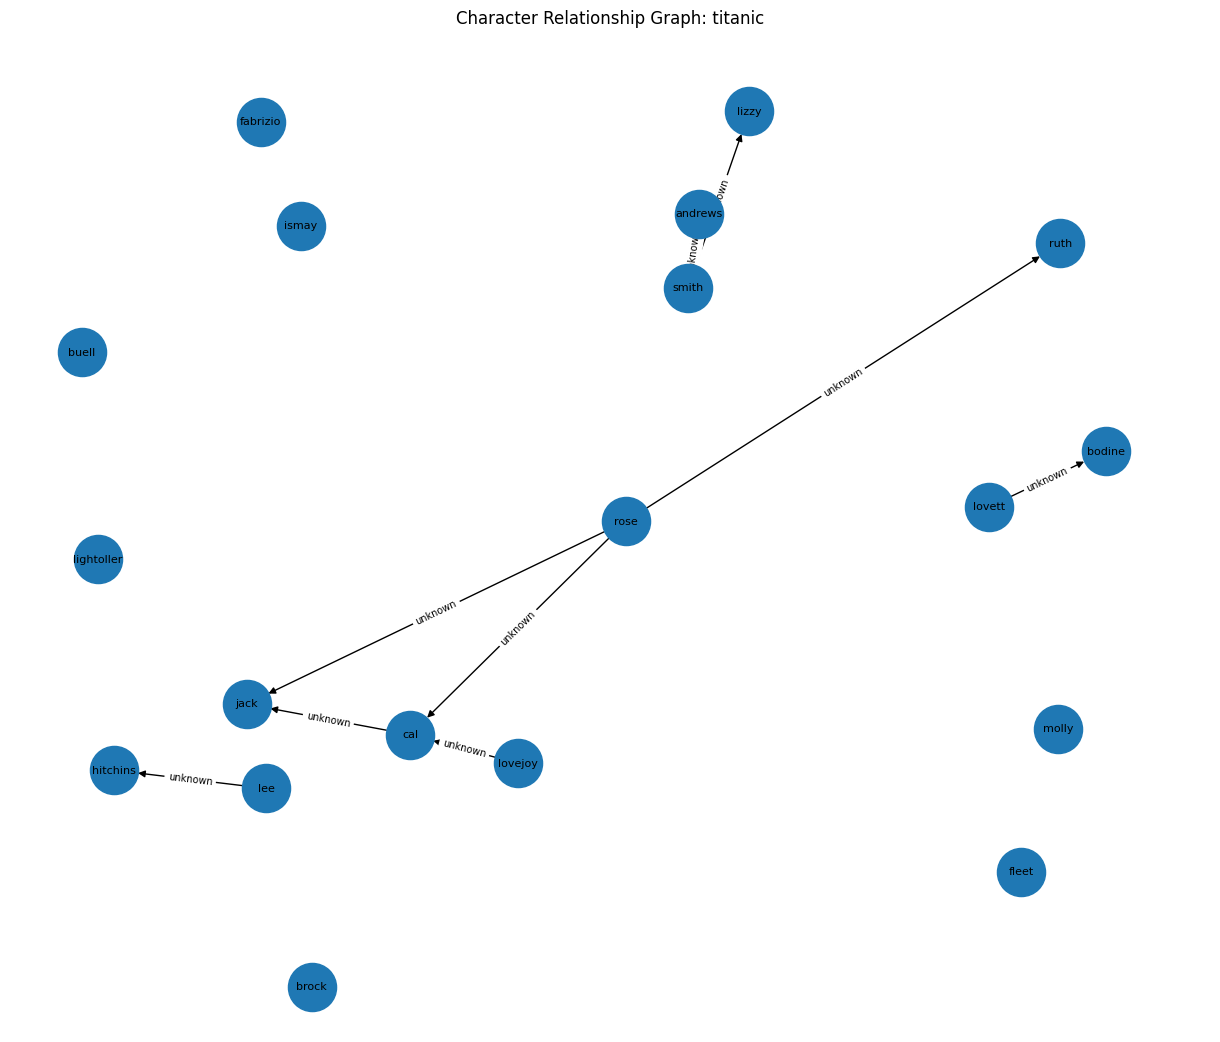

In [62]:
# ============================================================
# 21. Optional graph visualization
# ============================================================

try:
    import networkx as nx
    import matplotlib.pyplot as plt

    G = nx.DiGraph()

    for _, row in nodes_df.iterrows():
        G.add_node(row["name"], node_type=row["node_type"])

    for _, row in edges_df.iterrows():
        G.add_edge(
            row["source"],
            row["target"],
            relation_type=row["relation_type"],
            weight=row["final_confidence"],
        )

    if len(G.nodes) > 0:
        plt.figure(figsize=(12, 10))
        pos = nx.spring_layout(G, seed=42)
        nx.draw(G, pos, with_labels=True, node_size=1200, font_size=8, arrows=True)

        edge_labels = {(u, v): d["relation_type"] for u, v, d in G.edges(data=True)}
        nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=7)

        plt.title(f"Character Relationship Graph: {SELECTED_MOVIE_TITLE}")
        plt.show()
    else:
        print("No graph to draw yet.")

except ImportError:
    print("Install networkx and matplotlib if you want graph visualization.")


## 22. Recommended improvements

### 1. Two-stage extraction
先抽角色，再抽關係，通常更穩。

### 2. Global merge pass with Gemini
把所有 chunk 的候選角色名再丟一次 Gemini 做 canonicalization。

### 3. Relation timeline
同一對角色在不同段落的關係會演化，可做動態圖。

### 4. Scene-aware chunking
若之後有 scene segmentation，效果通常更好。

### 5. Gold set evaluation
手標少量片段，比較不同 prompt、模型、chunk 策略。
